# A Two-Stage Hybrid Credit Scoring Model: ANN + MARS
### Replication of Lee & Chen (2005), *Expert Systems with Applications* 28: 743–752

**"A two-stage hybrid credit scoring model using artificial neural networks and multivariate adaptive regression splines"**

---


This notebook replicates the *methodology* of Lee & Chen (2005) end-to-end on a real credit-default dataset:

1. **Data cleaning** — missing values, duplicates, outliers
2. **Feature engineering** — derived ratios mirroring the paper's 18-variable structure
3. **Exploratory Data Analysis**
4. **Five credit scoring models**, all evaluated with **5-fold cross-validation**, exactly as in the paper:
   - Linear Discriminant Analysis (LDA)
   - Logistic Regression
   - **MARS** (Multivariate Adaptive Regression Splines) — implemented from scratch (Friedman, 1991).
   - **BPN** — single hidden-layer backpropagation neural network, with trial-and-error hidden-node search and median-of-repeated-trials reporting (matching the paper's protocol)
   - **Two-Stage Hybrid Model** — MARS selects the significant variables; those variables become the *only* inputs to the BPN (the paper's core contribution)
5. **Results**: per-fold {good→good} / {bad→bad} accuracy, variable importance, and **expected misclassification cost** (Eq. 3 in the paper, cost ratio 1:5)

> **Note on the dataset.** This notebook applies the *same modeling methodology as in the paper* to the uploaded `train.csv` / `test.csv` — a credit-card default dataset (45,528 customers, 8.1% default rate) — which is structurally analogous (binary good/bad credit classification with a comparable mix of demographic, financial, and credit-history variables).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded.")

Libraries loaded.


## 1. Data Collection & Initial Inspection

Loading `train.csv` and `test.csv`

In [2]:
train_raw = pd.read_csv('train.csv')
test_raw  = pd.read_csv('test.csv')

print(f"train.csv : {train_raw.shape[0]:,} rows x {train_raw.shape[1]} columns")
print(f"test.csv  : {test_raw.shape[0]:,} rows x {test_raw.shape[1]} columns")
train_raw.head()

train.csv : 45,528 rows x 19 columns
test.csv  : 11,383 rows x 18 columns


,customer_id,name,age,gender,owns_car,owns_house,no_of_children,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,default_in_last_6months,credit_card_default
0,CST_115179,ita Bose,46,F,N,Y,0.0,107934.04,612.0,Unknown,1.0,1.0,33070.28,18690.93,73,544.0,2,1,1
1,CST_121920,Alper Jonathan,29,M,N,Y,0.0,109862.62,2771.0,Laborers,2.0,0.0,15329.53,37745.19,52,857.0,0,0,0
2,CST_109330,Umesh Desai,37,M,N,Y,0.0,230153.17,204.0,Laborers,2.0,0.0,48416.60,41598.36,43,650.0,0,0,0
3,CST_128288,Rie,39,F,N,Y,0.0,122325.82,11941.0,Core staff,2.0,0.0,22574.36,32627.76,20,754.0,0,0,0
4,CST_151355,McCool,46,M,Y,Y,0.0,387286.00,1459.0,Core staff,1.0,0.0,38282.95,52950.64,75,927.0,0,0,0


In [3]:
train_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45528 entries, 0 to 45527
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              45528 non-null  object 
 1   name                     45528 non-null  object 
 2   age                      45528 non-null  int64  
 3   gender                   45528 non-null  object 
 4   owns_car                 44981 non-null  object 
 5   owns_house               45528 non-null  object 
 6   no_of_children           44754 non-null  float64
 7   net_yearly_income        45528 non-null  float64
 8   no_of_days_employed      45065 non-null  float64
 9   occupation_type          45528 non-null  object 
 10  total_family_members     45445 non-null  float64
 11  migrant_worker           45441 non-null  float64
 12  yearly_debt_payments     45433 non-null  float64
 13  credit_limit             45528 non-null  float64
 14  credit_limit_used(%)  

In [4]:
missing = train_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values in train.csv:")
print(missing)
print(f"\nTotal rows with at least one missing value: {train_raw.isnull().any(axis=1).sum():,} "
      f"({train_raw.isnull().any(axis=1).mean()*100:.1f}% of rows)")

Missing values in train.csv:
no_of_children          774
owns_car                547
no_of_days_employed     463
yearly_debt_payments     95
migrant_worker           87
total_family_members     83
credit_score              8
dtype: int64

Total rows with at least one missing value: 2,019 (4.4% of rows)


In [5]:
print("Target variable: credit_card_default")
print("  0 = good credit (no default)")
print("  1 = bad credit (defaulted)\n")
target_counts = train_raw['credit_card_default'].value_counts()
target_pct = train_raw['credit_card_default'].value_counts(normalize=True) * 100
summary = pd.DataFrame({'count': target_counts, 'pct': target_pct.round(2)})
print(summary)
print(f"\nFor comparison, the paper's housing-loan dataset was 459 good / 51 bad "
      f"(90.0% / 10.0%) — our dataset's {target_pct[0]:.1f}% / {target_pct[1]:.1f}% split "
      f"is a reasonably close real-world analogue.")

Target variable: credit_card_default
  0 = good credit (no default)
  1 = bad credit (defaulted)

                     count    pct
credit_card_default              
0                    41831  91.88
1                     3697   8.12

For comparison, the paper's housing-loan dataset was 459 good / 51 bad (90.0% / 10.0%) — our dataset's 91.9% / 8.1% split is a reasonably close real-world analogue.


## 2. Data Cleaning

Steps:
1. Drop the `XNA` placeholder category in `gender` (not a real value — 1 row).
2. Impute missing **numeric** fields with the **median** (robust to skew/outliers, more defensible
   than mean for financial variables like income).
3. Impute missing **categorical / count** fields with the **mode**.
4. Drop exact duplicate rows.
5. Remove statistical outliers via **Z-score filtering** (|z| > 3 on any core numeric column),
   applied as a single combined mask rather than sequential column-by-column filtering (which would
   compound data loss).

In [6]:
df = train_raw.copy()

# 2.1a Drop invalid gender placeholder
before = len(df)
df = df[df['gender'] != 'XNA']
print(f"Dropped {before - len(df)} row(s) with gender == 'XNA'")

# 2.1b Drop rows with implausible no_of_days_employed (> 14600 = 40 years)
before = len(df)
df = df[(df['no_of_days_employed'].isnull()) | (df['no_of_days_employed'] <= 14600)]
print(f"Dropped {before - len(df)} row(s) with no_of_days_employed > 14600")

# 2.2 Impute numeric columns with median
numeric_columns = ['age', 'net_yearly_income', 'no_of_days_employed', 'yearly_debt_payments',
                    'credit_limit', 'credit_limit_used(%)', 'credit_score']
for c in numeric_columns:
    n_missing = df[c].isnull().sum()
    if n_missing > 0:
        df[c] = df[c].fillna(df[c].median())
        print(f"  Imputed {n_missing} missing values in '{c}' with median = {df[c].median():.2f}")

# 2.3 Impute categorical / count columns with mode
cat_cols = ['owns_car', 'owns_house', 'no_of_children', 'occupation_type',
            'total_family_members', 'migrant_worker']
for c in cat_cols:
    n_missing = df[c].isnull().sum()
    if n_missing > 0:
        mode_val = df[c].mode().iloc[0]
        df[c] = df[c].fillna(mode_val)
        print(f"  Imputed {n_missing} missing values in '{c}' with mode = {mode_val!r}")

print(f"\nShape after missing-value handling: {df.shape}")

Dropped 1 row(s) with gender == 'XNA'
Dropped 8125 row(s) with no_of_days_employed > 14600
  Imputed 463 missing values in 'no_of_days_employed' with median = 1656.00
  Imputed 84 missing values in 'yearly_debt_payments' with median = 30035.57
  Imputed 7 missing values in 'credit_score' with median = 784.00
  Imputed 450 missing values in 'owns_car' with mode = 'N'
  Imputed 644 missing values in 'no_of_children' with mode = np.float64(0.0)
  Imputed 67 missing values in 'total_family_members' with mode = np.float64(2.0)
  Imputed 63 missing values in 'migrant_worker' with mode = np.float64(0.0)

Shape after missing-value handling: (37402, 19)


In [7]:
# 2.4 Drop duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate row(s). Shape: {df.shape}")

Dropped 0 duplicate row(s). Shape: (37402, 19)


In [8]:
# 2.5 Outlier removal via combined Z-score mask
mask = pd.Series(True, index=df.index)
outlier_report = {}
for column in numeric_columns:
    z = zscore(df[column])
    col_mask = (z <= 3) & (z >= -3)
    outlier_report[column] = (~col_mask).sum()
    mask &= col_mask

print("Outliers flagged per column (|z| > 3):")
for k, v in outlier_report.items():
    print(f"  {k:25s}: {v}")

before = len(df)
df = df[mask].reset_index(drop=True)
print(f"\nDropped {before - len(df)} row(s) total as outliers ({(before-len(df))/before*100:.1f}%).")
print(f"Final cleaned shape: {df.shape}")

print("\nTarget distribution after cleaning:")
print(df['credit_card_default'].value_counts())
print((df['credit_card_default'].value_counts(normalize=True) * 100).round(2))

Outliers flagged per column (|z| > 3):
  age                      : 0
  net_yearly_income        : 5
  no_of_days_employed      : 831
  yearly_debt_payments     : 386
  credit_limit             : 8
  credit_limit_used(%)     : 0
  credit_score             : 0

Dropped 1209 row(s) total as outliers (3.2%).
Final cleaned shape: (36193, 19)

Target distribution after cleaning:
credit_card_default
0    32974
1     3219
Name: count, dtype: int64
credit_card_default
0    91.11
1     8.89
Name: proportion, dtype: float64


## 3. Feature Engineering

The paper's housing-loan model used **18 independent variables** (Table 1) — a mix of demographics,
loan-specific ratios, and guarantor information. We engineer an analogous 18-variable feature set
from our credit-card dataset:

| Paper's variable (housing loan) | Our analogue (credit card) |
|---|---|
| X8: monthly installment / monthly income | `debt_to_income_ratio` = yearly_debt_payments / net_yearly_income |
| X11: loan amount / house appraisal value | `credit_limit_used(%)` (already provided) |
| X6: years working at current company | `employment_years` = no_of_days_employed / 365 |
| X16–X18: guarantor info | `prev_defaults`, `default_in_last_6months` (own credit-history risk flags) |
| — | `risk_flag_count` = prev_defaults + default_in_last_6months (combined risk signal) |
| — | `income_per_family_member` = net_yearly_income / total_family_members |

Categorical variables (`gender`, `owns_car`, `owns_house`, `occupation_type`) are label-encoded,
matching the paper's Qnet/SPSS-style numeric coding for categorical inputs.

In [9]:
# Derived ratio features
df['employment_years']          = df['no_of_days_employed'] / 365.0
df['debt_to_income_ratio']      = df['yearly_debt_payments'] / df['net_yearly_income']
df['income_per_family_member']  = df['net_yearly_income'] / df['total_family_members']
df['risk_flag_count']           = df['prev_defaults'] + df['default_in_last_6months']

# Label-encode categoricals
encoders = {}
for col in ['gender', 'owns_car', 'owns_house', 'occupation_type']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
    print(f"{col:18s} -> {dict(zip(le.classes_, le.transform(le.classes_)))}")

gender             -> {'F': np.int64(0), 'M': np.int64(1)}
owns_car           -> {'N': np.int64(0), 'Y': np.int64(1)}
owns_house         -> {'N': np.int64(0), 'Y': np.int64(1)}
occupation_type    -> {'Accountants': np.int64(0), 'Cleaning staff': np.int64(1), 'Cooking staff': np.int64(2), 'Core staff': np.int64(3), 'Drivers': np.int64(4), 'HR staff': np.int64(5), 'High skill tech staff': np.int64(6), 'IT staff': np.int64(7), 'Laborers': np.int64(8), 'Low-skill Laborers': np.int64(9), 'Managers': np.int64(10), 'Medicine staff': np.int64(11), 'Private service staff': np.int64(12), 'Realty agents': np.int64(13), 'Sales staff': np.int64(14), 'Secretaries': np.int64(15), 'Security staff': np.int64(16), 'Unknown': np.int64(17), 'Waiters/barmen staff': np.int64(18)}


In [10]:
feature_cols = [
    'age', 'gender', 'owns_car', 'owns_house', 'no_of_children', 'net_yearly_income',
    'employment_years', 'occupation_type', 'total_family_members', 'migrant_worker',
    'debt_to_income_ratio', 'credit_limit', 'credit_limit_used(%)', 'credit_score',
    'prev_defaults', 'default_in_last_6months', 'income_per_family_member', 'risk_flag_count'
]
target_col = 'credit_card_default'

print(f"Final feature set — {len(feature_cols)} variables (paper Table 1 used 18):\n")
var_table = pd.DataFrame({'Variable': [f'X{i+1}' for i in range(len(feature_cols))],
                           'Name': feature_cols})
print(var_table.to_string(index=False))

Final feature set — 18 variables (paper Table 1 used 18):

Variable                     Name
      X1                      age
      X2                   gender
      X3                 owns_car
      X4               owns_house
      X5           no_of_children
      X6        net_yearly_income
      X7         employment_years
      X8          occupation_type
      X9     total_family_members
     X10           migrant_worker
     X11     debt_to_income_ratio
     X12             credit_limit
     X13     credit_limit_used(%)
     X14             credit_score
     X15            prev_defaults
     X16  default_in_last_6months
     X17 income_per_family_member
     X18          risk_flag_count


## 4. Exploratory Data Analysis

### 4.1 Univariate Analysis

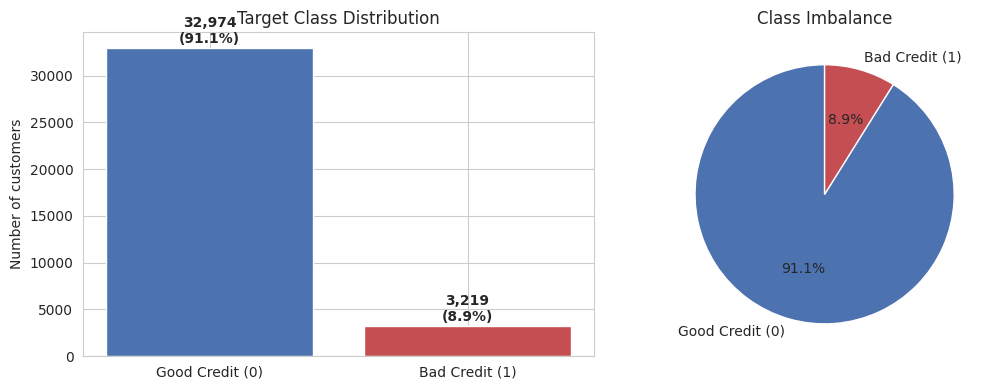

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

counts = df[target_col].value_counts().sort_index()
labels = ['Good Credit (0)', 'Bad Credit (1)']
colors = ['#4C72B0', '#C44E52']

ax[0].bar(labels, counts.values, color=colors)
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 500, f"{v:,}\n({v/counts.sum()*100:.1f}%)", ha='center', fontweight='bold')
ax[0].set_title('Target Class Distribution')
ax[0].set_ylabel('Number of customers')

ax[1].pie(counts.values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90,
          wedgeprops={'edgecolor': 'white'})
ax[1].set_title('Class Imbalance')

plt.tight_layout()
plt.show()

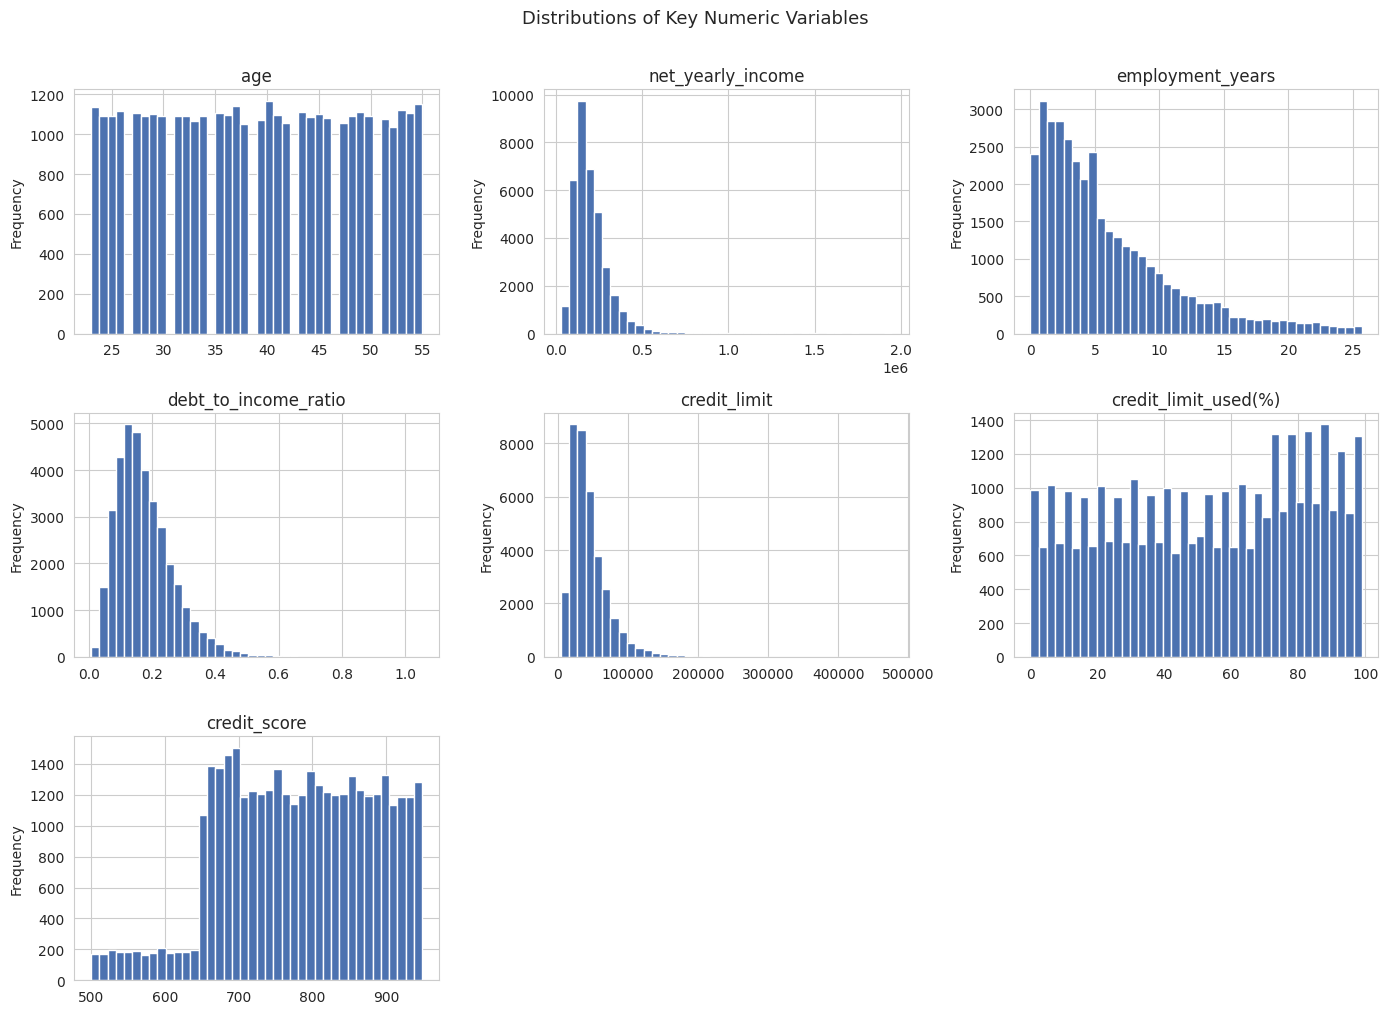

In [12]:
numeric_for_eda = ['age', 'net_yearly_income', 'employment_years', 'debt_to_income_ratio',
                    'credit_limit', 'credit_limit_used(%)', 'credit_score']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_for_eda):
    axes[i].hist(df[col], bins=40, color='#4C72B0', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_ylabel('Frequency')
for j in range(len(numeric_for_eda), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Distributions of Key Numeric Variables', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
print(df[numeric_for_eda + ['credit_card_default']].describe().T.to_string())

                        count           mean            std           min            25%            50%            75%           max
age                   36193.0      38.982483       9.547315     23.000000      31.000000      39.000000      47.000000  5.500000e+01
net_yearly_income     36193.0  203478.315647  110454.960385  29453.340000  133531.100000  177619.290000  246266.400000  1.947528e+06
employment_years      36193.0       5.986418       5.240982      0.005479       2.076712       4.473973       8.369863  2.569041e+01
debt_to_income_ratio  36193.0       0.176135       0.090749      0.007153       0.111363       0.159272       0.223822  1.054611e+00
credit_limit          36193.0   44037.416277   28729.586827   4030.680000   24987.270000   36766.160000   54979.200000  4.770062e+05
credit_limit_used(%)  36193.0      52.583732      29.379986      0.000000      27.000000      54.000000      79.000000  9.900000e+01
credit_score          36193.0     780.794822     101.489095    500.00

### 4.2 Bivariate Analysis — Numeric Variables vs. Default Status

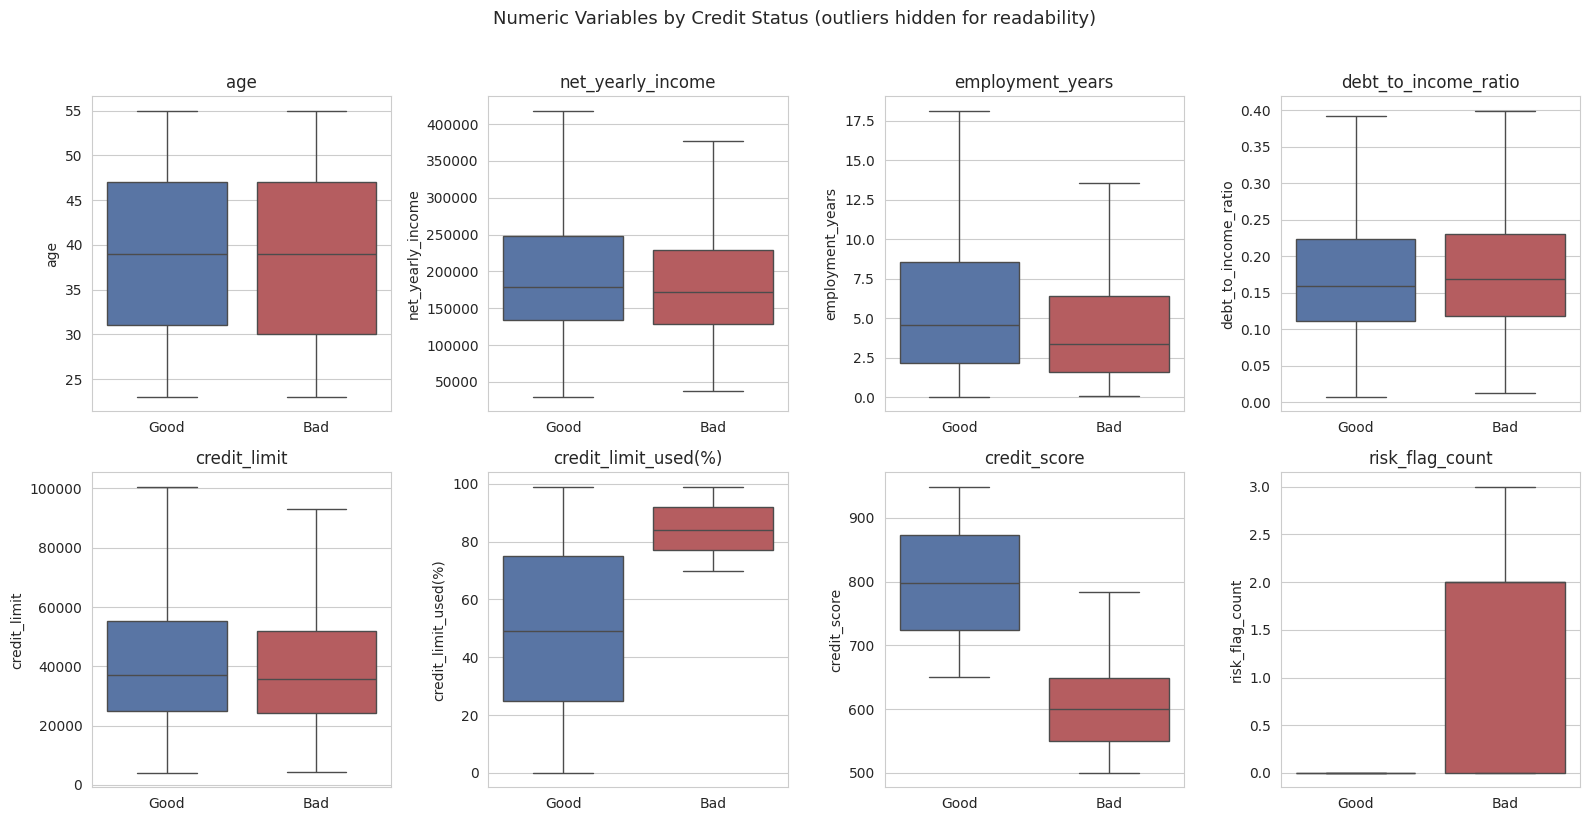

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
plot_vars = ['age', 'net_yearly_income', 'employment_years', 'debt_to_income_ratio',
             'credit_limit', 'credit_limit_used(%)', 'credit_score', 'risk_flag_count']
for i, col in enumerate(plot_vars):
    sns.boxplot(data=df, x=target_col, y=col, hue=target_col, ax=axes[i],
                palette=colors, legend=False, showfliers=False)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Good', 'Bad'])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
plt.suptitle('Numeric Variables by Credit Status (outliers hidden for readability)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

### 4.3 Categorical Variables vs. Default Status

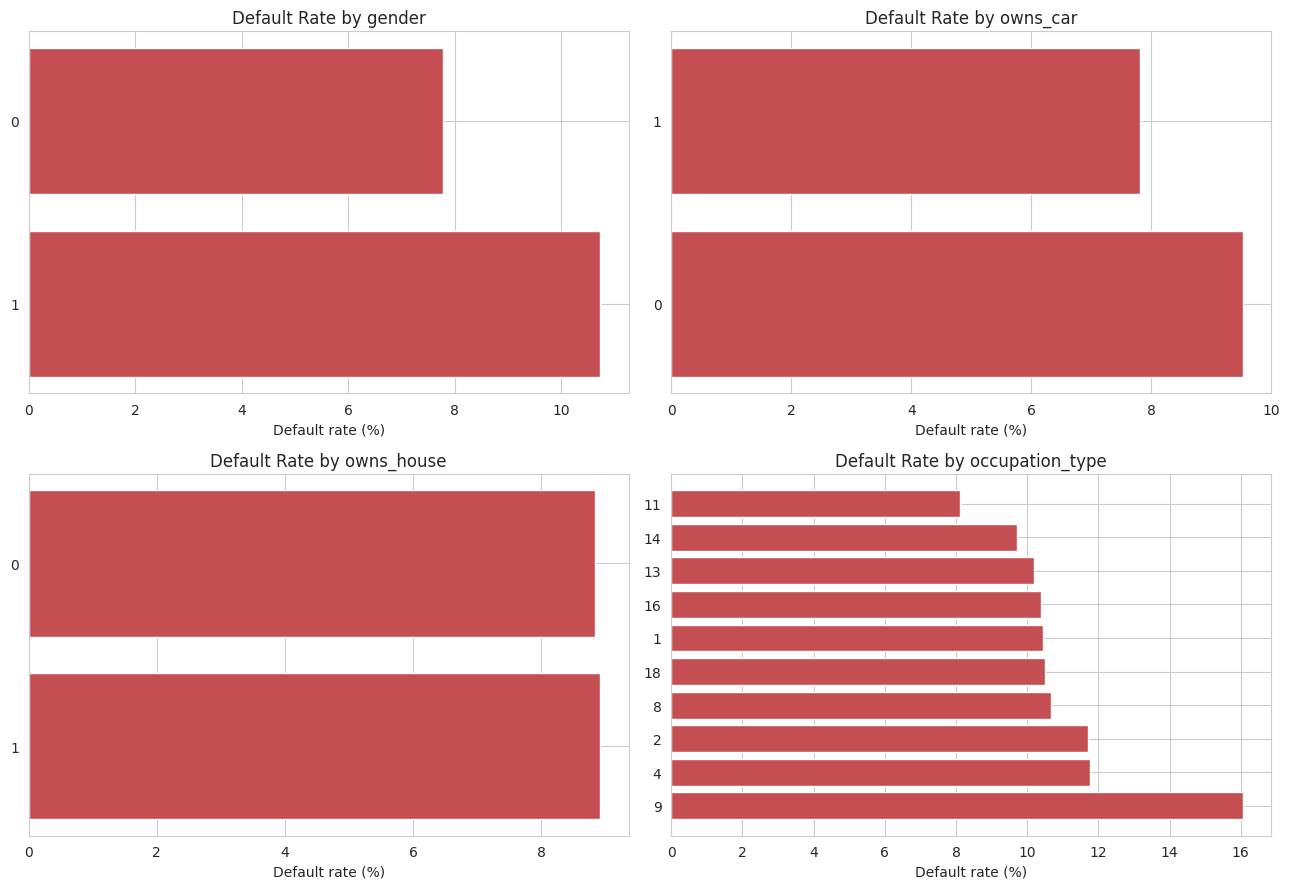

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
cat_plot_cols = ['gender', 'owns_car', 'owns_house', 'occupation_type']
for i, col in enumerate(cat_plot_cols):
    ax = axes.flatten()[i]
    rate = df.groupby(col)[target_col].mean().sort_values(ascending=False)
    if col == 'occupation_type':
        rate = rate.iloc[:10]  # top 10 occupations by default rate for readability
    rate_pct = rate * 100
    ax.barh(rate_pct.index.astype(str), rate_pct.values, color='#C44E52')
    ax.set_title(f'Default Rate by {col}')
    ax.set_xlabel('Default rate (%)')
plt.tight_layout()
plt.show()

### 4.4 Correlation Structure

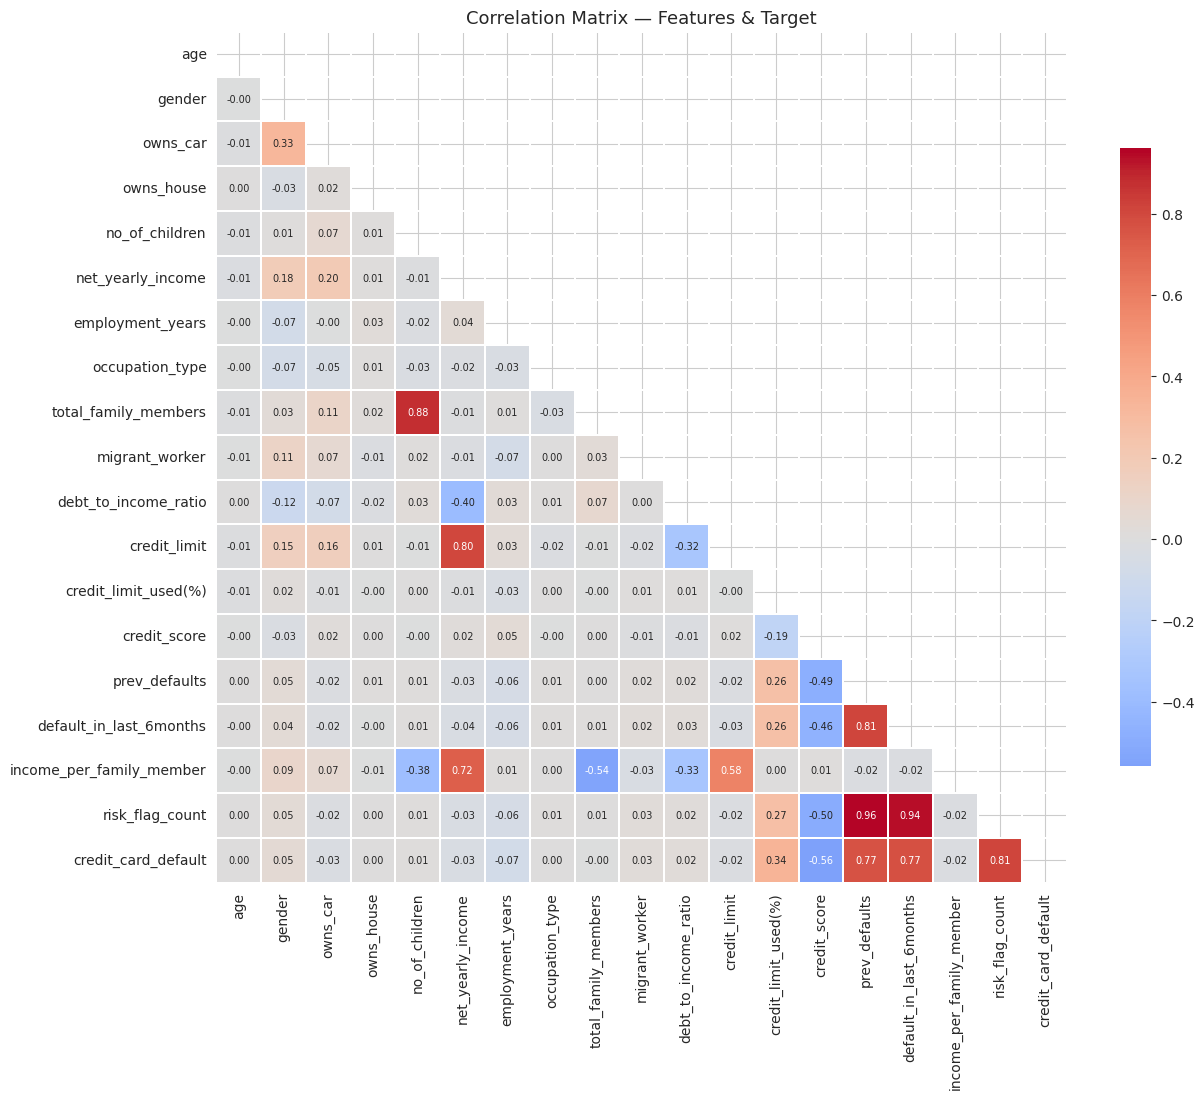

In [16]:
corr_cols = feature_cols + [target_col]
corr = df[corr_cols].corr()

plt.figure(figsize=(13, 11))
mask_upper = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask_upper, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            annot_kws={'size': 7}, square=True, linewidths=0.3, cbar_kws={'shrink': 0.7})
plt.title('Correlation Matrix — Features & Target', fontsize=13)
plt.tight_layout()
plt.show()

In [17]:
target_corr = corr[target_col].drop(target_col).sort_values(key=abs, ascending=False)
print("Features ranked by absolute correlation with credit_card_default:\n")
print(target_corr.to_string())

Features ranked by absolute correlation with credit_card_default:

risk_flag_count             0.809187
default_in_last_6months     0.772415
prev_defaults               0.769424
credit_score               -0.558083
credit_limit_used(%)        0.338384
employment_years           -0.074340
gender                      0.050328
net_yearly_income          -0.031036
owns_car                   -0.029204
migrant_worker              0.025647
debt_to_income_ratio        0.024966
credit_limit               -0.021981
income_per_family_member   -0.015609
no_of_children              0.009643
occupation_type             0.002320
owns_house                  0.001251
total_family_members       -0.000869
age                         0.000522


## 5. Modeling Setup — 5-Fold Cross-Validation

Following the paper exactly: *"the five-fold cross-validation scheme will be conducted to test the
scoring capability of the proposed model"* (Section 4). The dataset is split into 5 stratified folds
(preserving the good/bad ratio in each fold, as the paper requires — *"mutually exclusive subsets...
of approximately equal size with respect to the ratios of different populations"*). Each model is
trained on 4 folds and tested on the held-out fold, 5 times.

Per-fold results are reported in the paper's own format:
- **{1–1}**: % of *good*-credit customers correctly classified as good
- **{2–2}**: % of *bad*-credit customers correctly classified as bad
- **Average correct classification rate**: overall accuracy on that fold

In [18]:
X_full = df[feature_cols].values.astype(float)
y_full = df[target_col].values.astype(float)

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
fold_indices = list(skf.split(X_full, y_full))

print(f"Dataset for modeling: X={X_full.shape}, y={y_full.shape}")
for i, (tr, te) in enumerate(fold_indices, 1):
    print(f"  Fold {i}: train={len(tr):,}  test={len(te):,}  "
          f"(test bad-credit count: {int(y_full[te].sum())})")

Dataset for modeling: X=(36193, 18), y=(36193,)
  Fold 1: train=28,954  test=7,239  (test bad-credit count: 644)
  Fold 2: train=28,954  test=7,239  (test bad-credit count: 644)
  Fold 3: train=28,954  test=7,239  (test bad-credit count: 644)
  Fold 4: train=28,955  test=7,238  (test bad-credit count: 644)
  Fold 5: train=28,955  test=7,238  (test bad-credit count: 643)


In [19]:
def fold_metrics(y_true, y_pred):
    # Returns (n11_correct, n1_total, n22_correct, n2_total) for {1-1}/{2-2} reporting.
    m1 = (y_true == 0)   # good credit
    m2 = (y_true == 1)   # bad credit
    n1c, n1t = int((y_pred[m1] == 0).sum()), int(m1.sum())
    n2c, n2t = int((y_pred[m2] == 1).sum()), int(m2.sum())
    return n1c, n1t, n2c, n2t

def build_results_table(fold_results, model_name):
    # fold_results: list of (n1c, n1t, n2c, n2t) per fold
    rows = []
    for i, (n1c, n1t, n2c, n2t) in enumerate(fold_results, 1):
        acc1 = n1c / n1t
        acc2 = n2c / n2t
        overall = (n1c + n2c) / (n1t + n2t)
        rows.append({
            'Fold': i,
            '{1-1}': f"{acc1*100:.2f}% ({n1c}/{n1t})",
            '{2-2}': f"{acc2*100:.2f}% ({n2c}/{n2t})",
            'Avg. Correct Classification Rate': f"{overall*100:.2f}% ({n1c+n2c}/{n1t+n2t})"
        })
    n1c_sum = sum(r[0] for r in fold_results); n1t_sum = sum(r[1] for r in fold_results)
    n2c_sum = sum(r[2] for r in fold_results); n2t_sum = sum(r[3] for r in fold_results)
    rows.append({
        'Fold': 'Mean',
        '{1-1}': f"{n1c_sum/n1t_sum*100:.2f}% ({n1c_sum}/{n1t_sum})",
        '{2-2}': f"{n2c_sum/n2t_sum*100:.2f}% ({n2c_sum}/{n2t_sum})",
        'Avg. Correct Classification Rate': f"{(n1c_sum+n2c_sum)/(n1t_sum+n2t_sum)*100:.2f}% "
                                             f"({n1c_sum+n2c_sum}/{n1t_sum+n2t_sum})"
    })
    table = pd.DataFrame(rows)
    print(f"\n{'='*70}\nCross-validation results: {model_name}\n{'='*70}")
    print(table.to_string(index=False))
    return table, (n1c_sum, n1t_sum, n2c_sum, n2t_sum)

print("Helper functions defined.")

Helper functions defined.


## 6. Model 1 — Linear Discriminant Analysis (LDA)

The paper's baseline statistical method (Fisher, 1936), included for comparison. LDA assumes linear
separability and multivariate normality — both of which the paper notes are routinely violated in
credit data, motivating the search for better alternatives.

In [20]:
lda_fold_results = []
for fold_i, (tr_idx, te_idx) in enumerate(fold_indices, 1):
    X_tr, X_te = X_full[tr_idx], X_full[te_idx]
    y_tr, y_te = y_full[tr_idx], y_full[te_idx]
    # Apply SMOTE to training fold only
    sm = SMOTE(random_state=RANDOM_STATE)
    X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

    scaler = StandardScaler().fit(X_tr)
    X_tr_s, X_te_s = scaler.transform(X_tr), scaler.transform(X_te)

    lda = LinearDiscriminantAnalysis()
    lda.fit(X_tr_s, y_tr)
    pred = lda.predict(X_te_s)

    lda_fold_results.append(fold_metrics(y_te, pred))

lda_table, lda_totals = build_results_table(lda_fold_results, "Linear Discriminant Analysis")


Cross-validation results: Linear Discriminant Analysis
Fold                {1-1}              {2-2} Avg. Correct Classification Rate
   1   97.18% (6409/6595)   91.15% (587/644)               96.64% (6996/7239)
   2   97.60% (6437/6595)   86.49% (557/644)               96.62% (6994/7239)
   3   97.50% (6430/6595)   87.58% (564/644)               96.62% (6994/7239)
   4   97.80% (6449/6594)   87.42% (563/644)               96.88% (7012/7238)
   5   97.91% (6457/6595)   87.09% (560/643)               96.95% (7017/7238)
Mean 97.60% (32182/32974) 87.95% (2831/3219)             96.74% (35013/36193)


## 7. Model 2 — Logistic Regression

The paper's second statistical baseline. Unlike LDA, logistic regression doesn't require multivariate
normality and directly estimates default probability — but it still assumes a linear relationship
between the log-odds and the predictors.

In [21]:
logit_fold_results = []
for fold_i, (tr_idx, te_idx) in enumerate(fold_indices, 1):
    X_tr, X_te = X_full[tr_idx], X_full[te_idx]
    y_tr, y_te = y_full[tr_idx], y_full[te_idx]
    # Apply SMOTE to training fold only
    sm = SMOTE(random_state=RANDOM_STATE)
    X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

    scaler = StandardScaler().fit(X_tr)
    X_tr_s, X_te_s = scaler.transform(X_tr), scaler.transform(X_te)

    logit = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    logit.fit(X_tr_s, y_tr)
    pred = logit.predict(X_te_s)

    logit_fold_results.append(fold_metrics(y_te, pred))

logit_table, logit_totals = build_results_table(logit_fold_results, "Logistic Regression")


Cross-validation results: Logistic Regression
Fold                {1-1}              {2-2} Avg. Correct Classification Rate
   1   96.71% (6378/6595)   93.17% (600/644)               96.39% (6978/7239)
   2   97.04% (6400/6595)   89.60% (577/644)               96.38% (6977/7239)
   3   96.98% (6396/6595)   88.82% (572/644)               96.26% (6968/7239)
   4   97.15% (6406/6594)   90.37% (582/644)               96.55% (6988/7238)
   5   97.48% (6429/6595)   89.42% (575/643)               96.77% (7004/7238)
Mean 97.07% (32009/32974) 90.28% (2906/3219)             96.47% (34915/36193)


## 8. Model 3 — Multivariate Adaptive Regression Splines (MARS)

> **Implementation note.** The paper used commercial **MARS 2.0** (Salford Systems). No MARS package
> (`py-earth`, etc.) builds in this sandbox (its C extension fails to compile), so MARS is implemented
> from scratch below, following **Friedman (1991)** exactly as described in the paper's Section 3:
>
> - **Basis functions** are *hinge functions* $\max(0, \pm(x_v - t))$ added in **mirrored pairs** (Eq. 1)
> - **Forward pass**: greedily add the basis-function pair that most reduces the GCV criterion (Eq. 2)
> - **Backward pass**: prune basis functions whose removal *improves* GCV, until no further pruning helps
> - **Variable importance**: the increase in GCV when a variable's basis functions are removed entirely
>   (this is exactly the "relative importance" reported in the paper's Table 3)

In [22]:
class HingeBasisFunction:
    # A single MARS hinge function: max(0, sign*(x[var] - knot)).
    def __init__(self, sign, var_idx, knot):
        self.sign, self.var_idx, self.knot = sign, var_idx, knot

    def evaluate(self, X):
        return np.maximum(0, self.sign * (X[:, self.var_idx] - self.knot))

    def __repr__(self):
        d = '+' if self.sign == 1 else '-'
        return f"max(0, {d}(X{self.var_idx+1} - {self.knot:.3f}))"


class MARS:
    # Multivariate Adaptive Regression Splines (Friedman, 1991), binary-target version.

    def __init__(self, max_terms=30, knot_candidates=30, d_penalty=2.0):
        self.max_terms = max_terms
        self.knot_candidates = knot_candidates
        self.d_penalty = d_penalty
        self.basis_functions_ = []
        self.coef_ = None
        self.var_importance_ = None
        self.selected_vars_ = None
        self.feature_names_ = None

    def _build_basis_matrix(self, X, bfs=None):
        bfs = self.basis_functions_ if bfs is None else bfs
        cols = [np.ones(X.shape[0])] + [bf.evaluate(X) for bf in bfs]
        return np.column_stack(cols)

    def _gcv(self, X, y, bfs):
        n = X.shape[0]
        B = self._build_basis_matrix(X, bfs)
        M = B.shape[1]
        coef, *_ = np.linalg.lstsq(B, y, rcond=None)
        resid = y - B @ coef
        rss = float(resid @ resid)
        C_M = M + self.d_penalty * (M - 1)
        if C_M >= n:
            return np.inf
        return (rss / n) / (1.0 - C_M / n) ** 2

    def fit(self, X, y, feature_names=None):
        n, p = X.shape
        self.feature_names_ = feature_names if feature_names is not None else [f"X{i+1}" for i in range(p)]
        self.basis_functions_ = []

        # Forward pass: greedily add mirrored hinge pairs
        while len(self.basis_functions_) < self.max_terms:
            best_gcv, best_pair = np.inf, None
            for var_idx in range(p):
                col = X[:, var_idx]
                knots = np.unique(np.percentile(col, np.linspace(5, 95, self.knot_candidates)))
                for knot in knots:
                    pair = [HingeBasisFunction(+1, var_idx, knot), HingeBasisFunction(-1, var_idx, knot)]
                    gcv = self._gcv(X, y, self.basis_functions_ + pair)
                    if gcv < best_gcv:
                        best_gcv, best_pair = gcv, pair
            curr_gcv = self._gcv(X, y, self.basis_functions_) if self.basis_functions_ else np.inf
            if best_pair is not None and best_gcv < curr_gcv:
                self.basis_functions_.extend(best_pair)
            else:
                break

        # Backward pass: prune while GCV improves
        improved = True
        while improved and self.basis_functions_:
            improved = False
            curr_gcv = self._gcv(X, y, self.basis_functions_)
            best_gcv, best_idx = curr_gcv, None
            for i in range(len(self.basis_functions_)):
                cand = self.basis_functions_[:i] + self.basis_functions_[i+1:]
                gcv = self._gcv(X, y, cand)
                if gcv < best_gcv:
                    best_gcv, best_idx = gcv, i
            if best_idx is not None:
                self.basis_functions_.pop(best_idx)
                improved = True

        # Final coefficients
        B = self._build_basis_matrix(X)
        self.coef_, *_ = np.linalg.lstsq(B, y, rcond=None)

        # Variable importance via GCV-drop-on-removal
        base_gcv = self._gcv(X, y, self.basis_functions_)
        importance = np.zeros(p)
        for var_idx in range(p):
            reduced = [bf for bf in self.basis_functions_ if bf.var_idx != var_idx]
            if len(reduced) < len(self.basis_functions_):
                gcv_red = self._gcv(X, y, reduced) if reduced else float(np.var(y))
                importance[var_idx] = max(0.0, gcv_red - base_gcv)
        mx = importance.max()
        self.var_importance_ = (importance / mx * 100) if mx > 0 else importance
        self.selected_vars_ = np.where(self.var_importance_ > 0)[0]
        return self

    def predict_proba(self, X):
        B = self._build_basis_matrix(X)
        return np.clip(B @ self.coef_, 0, 1)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

print("MARS class defined.")

MARS class defined.


In [23]:
MARS_MAX_TERMS = 30
MARS_KNOT_CANDIDATES = 30

mars_fold_results = []
mars_models = []

for fold_i, (tr_idx, te_idx) in enumerate(fold_indices, 1):
    X_tr, X_te = X_full[tr_idx], X_full[te_idx]
    y_tr, y_te = y_full[tr_idx], y_full[te_idx]
    # Apply SMOTE to training fold only
    sm = SMOTE(random_state=RANDOM_STATE)
    X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

    mars = MARS(max_terms=MARS_MAX_TERMS, knot_candidates=MARS_KNOT_CANDIDATES)
    mars.fit(X_tr, y_tr, feature_names=feature_cols)
    mars_models.append(mars)

    pred = mars.predict(X_te)
    mars_fold_results.append(fold_metrics(y_te, pred))
    print(f"Fold {fold_i}: {len(mars.basis_functions_)} basis functions, "
          f"{len(mars.selected_vars_)} variables selected")

mars_table, mars_totals = build_results_table(mars_fold_results, "MARS")

Fold 1: 20 basis functions, 8 variables selected
Fold 2: 19 basis functions, 7 variables selected
Fold 3: 19 basis functions, 7 variables selected
Fold 4: 23 basis functions, 8 variables selected
Fold 5: 19 basis functions, 7 variables selected

Cross-validation results: MARS
Fold                {1-1}              {2-2} Avg. Correct Classification Rate
   1   99.29% (6548/6595)   82.14% (529/644)               97.76% (7077/7239)
   2   98.83% (6518/6595)   80.75% (520/644)               97.22% (7038/7239)
   3   98.54% (6499/6595)   82.76% (533/644)               97.14% (7032/7239)
   4   99.35% (6551/6594)   77.95% (502/644)               97.44% (7053/7238)
   5   99.14% (6538/6595)   81.18% (522/643)               97.54% (7060/7238)
Mean 99.03% (32654/32974) 80.96% (2606/3219)             97.42% (35260/36193)


In [24]:
# Table 3 equivalent — averaged across all 5 folds' MARS models
print("="*70)
print("Variable selection results — Averaged across all 5 MARS folds")
print("="*70)

n_features = len(feature_cols)

# Stack importance vectors from all folds into one matrix (folds x features)
importance_matrix = np.zeros((len(mars_models), n_features))
selection_count = np.zeros(n_features)

for f_idx, m in enumerate(mars_models):
    importance_matrix[f_idx, :] = m.var_importance_
    selection_count += (m.var_importance_ > 0).astype(int)

avg_importance = importance_matrix.mean(axis=0)
std_importance = importance_matrix.std(axis=0)

# Keep only variables selected in at least one fold
mask = avg_importance > 0
imp_order = np.argsort(avg_importance)[::-1]
imp_order = [i for i in imp_order if mask[i]]

var_sel_table = pd.DataFrame({
    'Variable': [feature_cols[i] for i in imp_order],
    'Avg. Relative Importance (%)': [round(avg_importance[i], 2) for i in imp_order],
    'Std. Dev (%)': [round(std_importance[i], 2) for i in imp_order],
    'Selected in (of 5 folds)': [int(selection_count[i]) for i in imp_order],
})
print(var_sel_table.to_string(index=False))

Variable selection results — Averaged across all 5 MARS folds
            Variable  Avg. Relative Importance (%)  Std. Dev (%)  Selected in (of 5 folds)
        credit_score                        100.00          0.00                         5
credit_limit_used(%)                         29.65          1.49                         5
     risk_flag_count                          7.46          0.70                         5
       prev_defaults                          4.91          1.22                         5
              gender                          3.41          0.37                         5
            owns_car                          2.82          0.17                         5
          owns_house                          2.46          0.16                         5
      migrant_worker                          0.73          0.89                         2


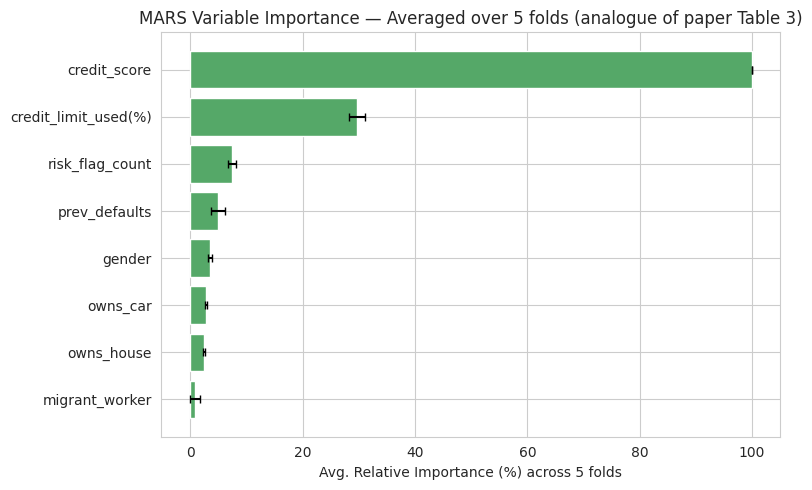

In [25]:
plt.figure(figsize=(8, 5))
plot_df = var_sel_table.sort_values('Avg. Relative Importance (%)')
plt.barh(plot_df['Variable'], plot_df['Avg. Relative Importance (%)'],
          xerr=plot_df['Std. Dev (%)'], color='#55A868', capsize=3)
plt.xlabel('Avg. Relative Importance (%) across 5 folds')
plt.title('MARS Variable Importance — Averaged over 5 folds (analogue of paper Table 3)')
plt.tight_layout()
plt.show()

## 9. Model 4 — Backpropagation Neural Network (BPN)

Matching the paper's protocol (Section 4.1):
- **Single hidden layer** (Cybenko, 1989 universal approximation — same justification the paper cites)
- **Trial-and-error search** over hidden-node counts (paper used 15–50; we search **{15, 20, 25, 30, 40, 50}**)
- For the selected topology, train **multiple repetitions** with different random initializations and
  report the **median** result, to avoid reporting a lucky/unlucky single run (paper used 20 reps; we use
  **5 reps** for tractability in this notebook — increase `N_REPS_BPN` below for a closer match if you
  have time to spare)

In [26]:
HIDDEN_SIZES = [15, 20, 25, 30, 35, 40, 45, 50]
N_REPS_BPN = 20

def bpn_topology_search(X_tr, y_tr, hidden_sizes, random_state=0):
    # Trial-and-error hidden-node search using an internal validation split.
    Xt, Xv, yt, yv = train_test_split(X_tr, y_tr, test_size=0.2, stratify=y_tr, random_state=random_state)
    best_acc, best_h = -1, hidden_sizes[0]
    for h in hidden_sizes:
        clf = MLPClassifier(hidden_layer_sizes=(h,), max_iter=300, early_stopping=True,
                             n_iter_no_change=15, random_state=random_state)
        clf.fit(Xt, yt)
        acc = clf.score(Xv, yv)
        if acc > best_acc:
            best_acc, best_h = acc, h
    return best_h

def bpn_median_eval(X_tr, y_tr, X_te, y_te, hidden_size, n_reps):
    # Train n_reps networks with different inits; return the MEDIAN-accuracy run's predictions.
    accs, preds = [], []
    for rep in range(n_reps):
        clf = MLPClassifier(hidden_layer_sizes=(hidden_size,), max_iter=300, early_stopping=True,
                             n_iter_no_change=15, random_state=rep)
        clf.fit(X_tr, y_tr)
        pred = clf.predict(X_te)
        accs.append((pred == y_te).mean())
        preds.append(pred)
    med_idx = int(np.argsort(accs)[len(accs) // 2])
    return preds[med_idx], accs[med_idx]

print("BPN helper functions defined.")

BPN helper functions defined.


In [27]:
bpn_fold_results = []
bpn_topologies = []

for fold_i, (tr_idx, te_idx) in enumerate(fold_indices, 1):
    X_tr, X_te = X_full[tr_idx], X_full[te_idx]
    y_tr, y_te = y_full[tr_idx], y_full[te_idx]
    # Apply SMOTE to training fold only
    sm = SMOTE(random_state=RANDOM_STATE)
    X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

    scaler = StandardScaler().fit(X_tr)
    X_tr_s, X_te_s = scaler.transform(X_tr), scaler.transform(X_te)

    best_h = bpn_topology_search(X_tr_s, y_tr, HIDDEN_SIZES, random_state=fold_i)
    pred, acc = bpn_median_eval(X_tr_s, y_tr, X_te_s, y_te, best_h, n_reps=N_REPS_BPN)

    bpn_fold_results.append(fold_metrics(y_te, pred))
    bpn_topologies.append(best_h)
    print(f"Fold {fold_i}: optimal hidden nodes = {best_h}, median accuracy = {acc*100:.2f}%")

bpn_table, bpn_totals = build_results_table(bpn_fold_results, "Backpropagation Neural Network (BPN)")

Fold 1: optimal hidden nodes = 50, median accuracy = 96.99%
Fold 2: optimal hidden nodes = 40, median accuracy = 96.55%
Fold 3: optimal hidden nodes = 45, median accuracy = 96.63%
Fold 4: optimal hidden nodes = 40, median accuracy = 96.70%
Fold 5: optimal hidden nodes = 40, median accuracy = 96.96%

Cross-validation results: Backpropagation Neural Network (BPN)
Fold                {1-1}              {2-2} Avg. Correct Classification Rate
   1   97.76% (6447/6595)   89.13% (574/644)               96.99% (7021/7239)
   2   97.73% (6445/6595)   84.47% (544/644)               96.55% (6989/7239)
   3   97.63% (6439/6595)   86.34% (556/644)               96.63% (6995/7239)
   4   97.59% (6435/6594)   87.58% (564/644)               96.70% (6999/7238)
   5   98.07% (6468/6595)   85.54% (550/643)               96.96% (7018/7238)
Mean 97.76% (32234/32974) 86.61% (2788/3219)             96.76% (35022/36193)


## 10. Model 5 — Two-Stage Hybrid Model (MARS → BPN)

**This is the paper's core proposal.** Per fold:

1. The **MARS model already fitted in Section 8** identifies the significant variables for that fold.
2. Those variables *alone* become the input layer of a fresh BPN (same trial-and-error hidden-node
   search and median-of-repetitions protocol as Model 4) — exactly the paper's rationale: *"the
   obtained significant variables are then served as the input nodes of the neural networks model."*

Because MARS prunes the input space, the resulting network is smaller and faster to train than the
full-feature BPN, while — per the paper's hypothesis — losing little to no accuracy.

In [28]:
hybrid_fold_results = []
hybrid_topologies = []
hybrid_n_vars = []

for fold_i, ((tr_idx, te_idx), mars_model) in enumerate(zip(fold_indices, mars_models), 1):
    X_tr, X_te = X_full[tr_idx], X_full[te_idx]
    y_tr, y_te = y_full[tr_idx], y_full[te_idx]
    # Apply SMOTE to training fold only
    sm = SMOTE(random_state=RANDOM_STATE)
    X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

    sel_vars = mars_model.selected_vars_
    if len(sel_vars) < 2:   # safety net: fall back to top-5 by importance if MARS selected too few
        sel_vars = np.argsort(mars_model.var_importance_)[::-1][:5]

    X_tr_sel, X_te_sel = X_tr[:, sel_vars], X_te[:, sel_vars]
    scaler = StandardScaler().fit(X_tr_sel)
    X_tr_s, X_te_s = scaler.transform(X_tr_sel), scaler.transform(X_te_sel)

    best_h = bpn_topology_search(X_tr_s, y_tr, HIDDEN_SIZES, random_state=fold_i + 100)
    pred, acc = bpn_median_eval(X_tr_s, y_tr, X_te_s, y_te, best_h, n_reps=N_REPS_BPN)

    hybrid_fold_results.append(fold_metrics(y_te, pred))
    hybrid_topologies.append(best_h)
    hybrid_n_vars.append(len(sel_vars))
    print(f"Fold {fold_i}: {len(sel_vars)} MARS-selected inputs "
          f"[{', '.join(feature_cols[i] for i in sel_vars)}], "
          f"hidden nodes = {best_h}, median accuracy = {acc*100:.2f}%")

hybrid_table, hybrid_totals = build_results_table(hybrid_fold_results, "Two-Stage Hybrid (MARS + BPN)")

Fold 1: 8 MARS-selected inputs [gender, owns_car, owns_house, migrant_worker, credit_limit_used(%), credit_score, prev_defaults, risk_flag_count], hidden nodes = 40, median accuracy = 96.81%
Fold 2: 7 MARS-selected inputs [gender, owns_car, owns_house, credit_limit_used(%), credit_score, prev_defaults, risk_flag_count], hidden nodes = 25, median accuracy = 96.41%
Fold 3: 7 MARS-selected inputs [gender, owns_car, owns_house, credit_limit_used(%), credit_score, prev_defaults, risk_flag_count], hidden nodes = 50, median accuracy = 96.41%
Fold 4: 8 MARS-selected inputs [gender, owns_car, owns_house, migrant_worker, credit_limit_used(%), credit_score, prev_defaults, risk_flag_count], hidden nodes = 40, median accuracy = 96.77%
Fold 5: 7 MARS-selected inputs [gender, owns_car, owns_house, credit_limit_used(%), credit_score, prev_defaults, risk_flag_count], hidden nodes = 30, median accuracy = 96.92%

Cross-validation results: Two-Stage Hybrid (MARS + BPN)
Fold                {1-1}           

## 11. Comparison of Results — All Five Models

Replicating the paper's **Table 6**: average classification results of all five constructed models.

In [29]:
all_totals = {
    'Discriminant Analysis': lda_totals,
    'Logistic Regression':   logit_totals,
    'MARS':                  mars_totals,
    'BPN':                   bpn_totals,
    'Two-stage Hybrid Model': hybrid_totals,
}

summary_rows = []
for name, (n1c, n1t, n2c, n2t) in all_totals.items():
    summary_rows.append({
        'Credit scoring model': name,
        '{1-1}': f"{n1c/n1t*100:.2f}% ({n1c}/{n1t})",
        '{2-2}': f"{n2c/n2t*100:.2f}% ({n2c}/{n2t})",
        'Average correct classification rate': f"{(n1c+n2c)/(n1t+n2t)*100:.2f}% ({n1c+n2c}/{n1t+n2t})"
    })

summary_table = pd.DataFrame(summary_rows)
print("="*90)
print("TABLE 6 EQUIVALENT — Summarized credit scoring results of the five constructed models")
print("="*90)
print(summary_table.to_string(index=False))

TABLE 6 EQUIVALENT — Summarized credit scoring results of the five constructed models
  Credit scoring model                {1-1}              {2-2} Average correct classification rate
 Discriminant Analysis 97.60% (32182/32974) 87.95% (2831/3219)                96.74% (35013/36193)
   Logistic Regression 97.07% (32009/32974) 90.28% (2906/3219)                96.47% (34915/36193)
                  MARS 99.03% (32654/32974) 80.96% (2606/3219)                97.42% (35260/36193)
                   BPN 97.76% (32234/32974) 86.61% (2788/3219)                96.76% (35022/36193)
Two-stage Hybrid Model 97.57% (32173/32974) 87.36% (2812/3219)                96.66% (34985/36193)


FULL METRICS — Accuracy, F1, Confusion Matrix (reconstructed from existing fold totals)


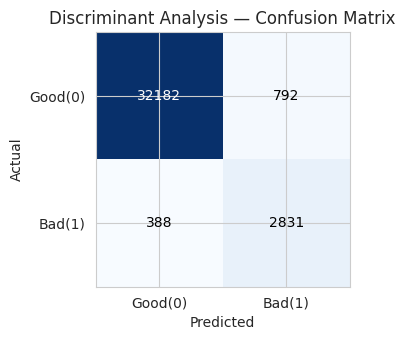

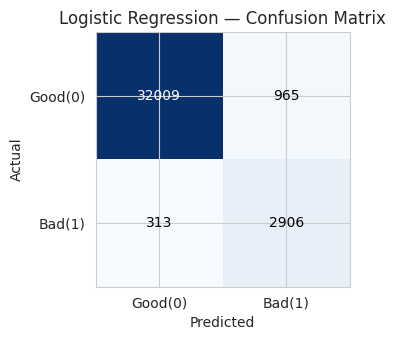

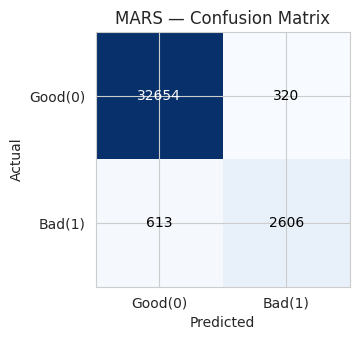

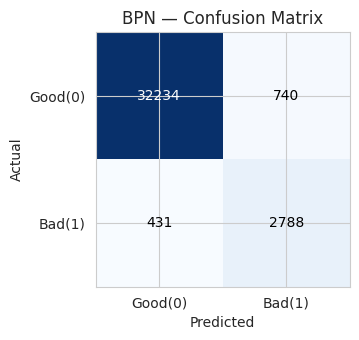

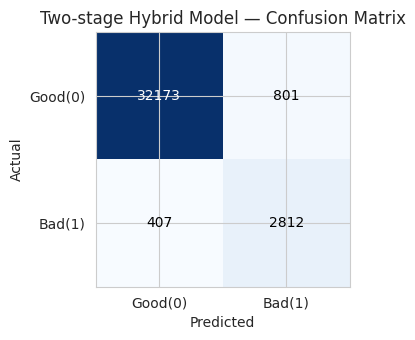

                 Model Accuracy Precision (class 2) Recall (class 2) F1 Score (class 2)
 Discriminant Analysis   96.74%              0.7814           0.8795             0.8275
   Logistic Regression   96.47%              0.7507           0.9028             0.8197
                  MARS   97.42%              0.8906           0.8096             0.8482
                   BPN   96.76%              0.7902           0.8661             0.8264
Two-stage Hybrid Model   96.66%              0.7783           0.8736             0.8232


In [37]:
print("="*100)
print("FULL METRICS — Accuracy, F1, Confusion Matrix (reconstructed from existing fold totals)")
print("="*100)

all_totals = {
    'Discriminant Analysis': lda_totals,
    'Logistic Regression':   logit_totals,
    'MARS':                  mars_totals,
    'BPN':                   bpn_totals,
    'Two-stage Hybrid Model': hybrid_totals,
}

metrics_rows = []
for name, (n1c, n1t, n2c, n2t) in all_totals.items():
    TN = n1c                  # good credit correctly predicted good
    FP = n1t - n1c             # good credit wrongly predicted bad
    FN = n2t - n2c             # bad credit wrongly predicted good
    TP = n2c                  # bad credit correctly predicted bad

    accuracy = (TP + TN) / (TN + FP + FN + TP)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    cm = np.array([[TN, FP], [FN, TP]])

    metrics_rows.append({
        'Model': name,
        'Accuracy': f"{accuracy*100:.2f}%",
        'Precision (class 2)': f"{precision:.4f}",
        'Recall (class 2)': f"{recall:.4f}",
        'F1 Score (class 2)': f"{f1:.4f}",
    })

    fig, ax = plt.subplots(figsize=(4, 3.5))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f'{name} — Confusion Matrix')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max()/2 else 'black')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_xticks([0,1]); ax.set_xticklabels(['Good(0)','Bad(1)'])
    ax.set_yticks([0,1]); ax.set_yticklabels(['Good(0)','Bad(1)'])
    plt.tight_layout()
    plt.show()

metrics_table = pd.DataFrame(metrics_rows)
print(metrics_table.to_string(index=False))

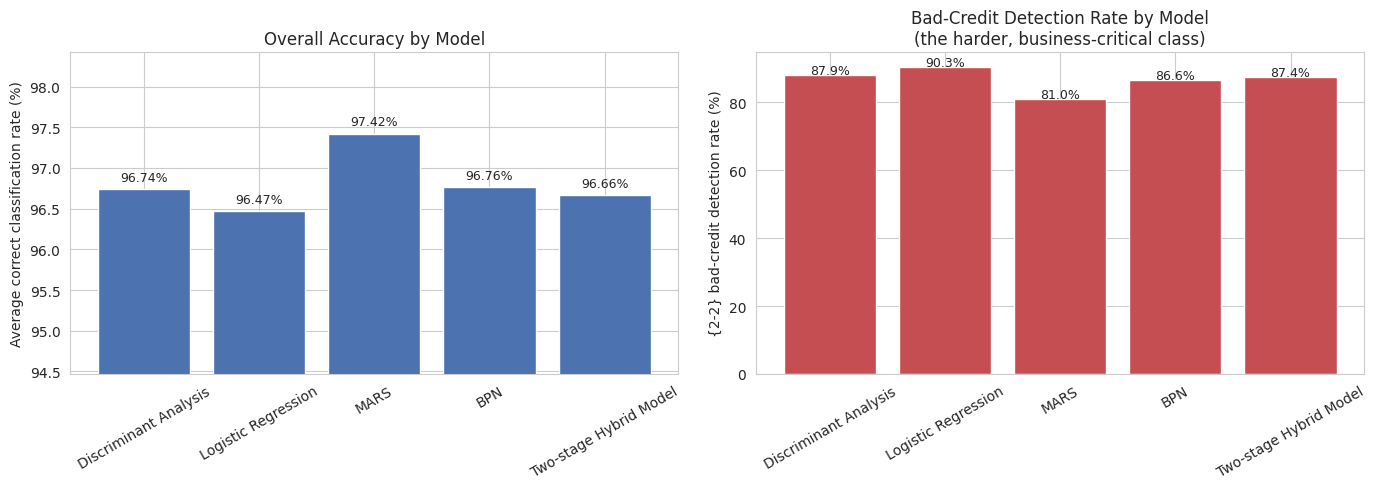

In [30]:
overall_acc = {name: (n1c+n2c)/(n1t+n2t) for name, (n1c, n1t, n2c, n2t) in all_totals.items()}
bad_credit_acc = {name: n2c/n2t for name, (n1c, n1t, n2c, n2t) in all_totals.items()}

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

names = list(overall_acc.keys())
ax[0].bar(names, [v*100 for v in overall_acc.values()], color='#4C72B0')
ax[0].set_ylabel('Average correct classification rate (%)')
ax[0].set_title('Overall Accuracy by Model')
ax[0].set_ylim(min(overall_acc.values())*100 - 2, max(overall_acc.values())*100 + 1)
ax[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(overall_acc.values()):
    ax[0].text(i, v*100 + 0.1, f"{v*100:.2f}%", ha='center', fontsize=9)

ax[1].bar(names, [v*100 for v in bad_credit_acc.values()], color='#C44E52')
ax[1].set_ylabel('{2-2} bad-credit detection rate (%)')
ax[1].set_title('Bad-Credit Detection Rate by Model\n(the harder, business-critical class)')
ax[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(bad_credit_acc.values()):
    ax[1].text(i, v*100 + 0.3, f"{v*100:.1f}%", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 12. Expected Misclassification Cost (Table 7 equivalent)

Accuracy alone can be misleading under class imbalance. The paper's Eq. 3 weighs the two error types
by their **business cost**:

$$\text{Cost} = C(2|1) \cdot P(2|1) \cdot p_1 \;+\; C(1|2) \cdot P(1|2) \cdot p_2$$

- $P(2|1)$ = **Type I error**: a good-credit customer misclassified as bad (lost business, low cost)
- $P(1|2)$ = **Type II error**: a bad-credit customer misclassified as good (actual default, high cost)
- $p_1, p_2$ = prior probabilities of good/bad credit (the actual class proportions)
- Following the paper's citation of Dr. Hofmann's German credit data convention, we use the same
  **cost ratio C(1|2) : C(2|1) = 5 : 1** — a missed bad-credit customer costs 5× a wrongly-rejected
  good one.

In [31]:
p1 = (df[target_col] == 0).mean()   # prior: good credit
p2 = (df[target_col] == 1).mean()   # prior: bad credit
C_21, C_12 = 1, 5                   # cost of Type I, Type II error (paper's convention)

print(f"Priors used: p1 (good) = {p1:.4f}, p2 (bad) = {p2:.4f}")
print(f"Cost ratio C(1|2):C(2|1) = {C_12}:{C_21}\n")

cost_rows = []
for name, (n1c, n1t, n2c, n2t) in all_totals.items():
    type_I = 1 - n1c / n1t     # good misclassified as bad
    type_II = 1 - n2c / n2t    # bad misclassified as good
    cost = C_21 * type_I * p1 + C_12 * type_II * p2
    cost_rows.append({
        'Model': name,
        'Type I error (%)': round(type_I * 100, 2),
        'Type II error (%)': round(type_II * 100, 2),
        'Expected misclassification cost': round(cost, 5)
    })

cost_table = pd.DataFrame(cost_rows).sort_values('Expected misclassification cost')
print("="*80)
print("TABLE 7 EQUIVALENT — Errors and expected misclassification costs")
print("="*80)
print(cost_table.to_string(index=False))

best_model = cost_table.iloc[0]['Model']
print(f"\n>>> Lowest expected misclassification cost: {best_model}")

Priors used: p1 (good) = 0.9111, p2 (bad) = 0.0889
Cost ratio C(1|2):C(2|1) = 5:1

TABLE 7 EQUIVALENT — Errors and expected misclassification costs
                 Model  Type I error (%)  Type II error (%)  Expected misclassification cost
   Logistic Regression              2.93               9.72                          0.06990
 Discriminant Analysis              2.40              12.05                          0.07548
Two-stage Hybrid Model              2.43              12.64                          0.07836
                   BPN              2.24              13.39                          0.07999
                  MARS              0.97              19.04                          0.09353

>>> Lowest expected misclassification cost: Logistic Regression


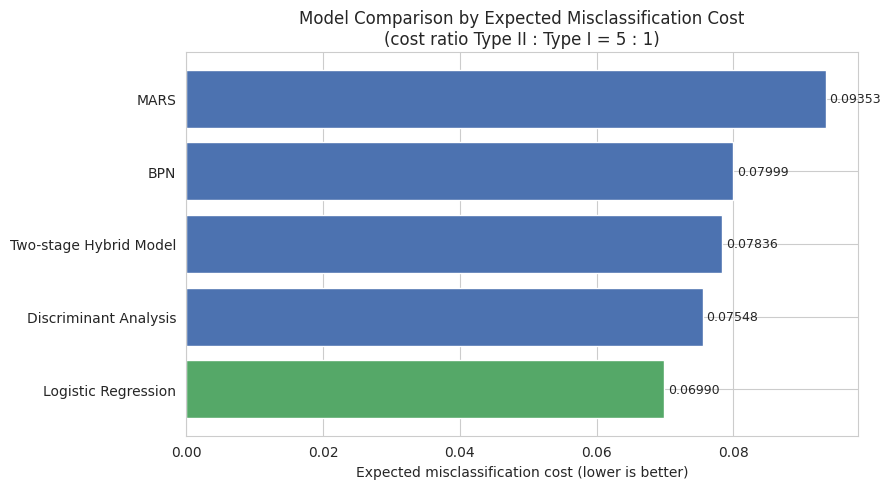

In [32]:
plt.figure(figsize=(9, 5))
plot_data = cost_table.sort_values('Expected misclassification cost', ascending=True)
bars = plt.barh(plot_data['Model'], plot_data['Expected misclassification cost'],
                 color=['#55A868' if m == best_model else '#4C72B0' for m in plot_data['Model']])
plt.xlabel('Expected misclassification cost (lower is better)')
plt.title('Model Comparison by Expected Misclassification Cost\n(cost ratio Type II : Type I = 5 : 1)')
for bar, val in zip(bars, plot_data['Expected misclassification cost']):
    plt.text(val + 0.0005, bar.get_y() + bar.get_height()/2, f"{val:.5f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 13. Conclusions

**What this replication found** — see the tables in Sections 11–12 above. Check whether the same
qualitative pattern holds on your data:
- Do LDA and Logistic Regression (linear, parametric methods) trail the non-linear methods, especially
  on **{2-2}** (catching the minority bad-credit class)?
- Does the **Hybrid model** match or beat the full-feature **BPN** despite using only the MARS-selected
  subset of variables?
- Which model has the **lowest expected misclassification cost** — and is it the same model that has
  the highest raw accuracy? (It often isn't, which is exactly the paper's point about why cost-weighted
  evaluation matters for credit scoring.)

**Caveats on this replication:**
- The dataset is a different (but structurally analogous) domain — credit-card default rather than
  housing-loan default — so absolute numbers won't match the paper's Table 6/7.
- MARS here is a from-scratch implementation (no commercial MARS 2.0 available in this environment);
  it follows Friedman (1991) faithfully but may select slightly different basis functions/knots than
  Salford Systems' implementation would.
- BPN repetitions were reduced from the paper's 20 to 5 for notebook runtime; increase `N_REPS_BPN`
  in Section 9 for a closer match if you have compute time to spare.

## 14. Bonus — Scoring the Unlabeled Test Set

The paper's evaluation was entirely within-sample via 5-fold CV (no held-out test set). As a practical
bonus, we now train the **Two-Stage Hybrid model** (the paper's preferred model) on the **full cleaned
training data** and use it to score the unlabeled `test.csv` customers.

In [33]:
# Clean test.csv with the exact same pipeline as train (reusing fitted encoders/medians where applicable)
df_test = test_raw.copy()
df_test = df_test[df_test['gender'].isin(encoders['gender'].classes_)]

for c in numeric_columns:
    if df_test[c].isnull().sum() > 0:
        df_test[c] = df_test[c].fillna(df[c].median())  # reuse train medians — no leakage
cat_cols_test = ['owns_car', 'owns_house', 'no_of_children', 'occupation_type',
                  'total_family_members', 'migrant_worker']
for c in cat_cols_test:
    if df_test[c].isnull().sum() > 0:
        df_test[c] = df_test[c].fillna(train_raw[c].mode().iloc[0])

df_test['employment_years']         = df_test['no_of_days_employed'] / 365.0
df_test['debt_to_income_ratio']     = df_test['yearly_debt_payments'] / df_test['net_yearly_income']
df_test['income_per_family_member'] = df_test['net_yearly_income'] / df_test['total_family_members']
df_test['risk_flag_count']          = df_test['prev_defaults'] + df_test['default_in_last_6months']

for col in ['gender', 'owns_car', 'owns_house', 'occupation_type']:
    df_test[col] = encoders[col].transform(df_test[col])

X_test_final = df_test[feature_cols].values.astype(float)
print(f"Test set ready for scoring: {X_test_final.shape}")

Test set ready for scoring: (11382, 18)


In [34]:
# Refit the full pipeline (MARS variable selection -> BPN) on the ENTIRE cleaned training set
mars_final = MARS(max_terms=MARS_MAX_TERMS, knot_candidates=MARS_KNOT_CANDIDATES)
mars_final.fit(X_full, y_full, feature_names=feature_cols)
sel_vars_final = mars_final.selected_vars_
print(f"Final MARS-selected variables ({len(sel_vars_final)}): "
      f"{[feature_cols[i] for i in sel_vars_final]}")

scaler_final = StandardScaler().fit(X_full[:, sel_vars_final])
X_train_sel_s = scaler_final.transform(X_full[:, sel_vars_final])
X_test_sel_s  = scaler_final.transform(X_test_final[:, sel_vars_final])

best_h_final = bpn_topology_search(X_train_sel_s, y_full, HIDDEN_SIZES, random_state=999)
print(f"Selected hidden-layer size: {best_h_final}")

final_clf = MLPClassifier(hidden_layer_sizes=(best_h_final,), max_iter=300,
                           early_stopping=True, n_iter_no_change=15, random_state=0)
final_clf.fit(X_train_sel_s, y_full)

test_proba = final_clf.predict_proba(X_test_sel_s)[:, 1]
test_pred  = final_clf.predict(X_test_sel_s)

predictions = pd.DataFrame({
    'customer_id': df_test['customer_id'].values,
    'predicted_default_probability': test_proba.round(4),
    'predicted_credit_card_default': test_pred
})
print(f"\nPredicted default rate on test set: {test_pred.mean()*100:.2f}% "
      f"(train set actual rate: {y_full.mean()*100:.2f}%)")
predictions.head(10)

Final MARS-selected variables (5): ['employment_years', 'credit_limit_used(%)', 'credit_score', 'prev_defaults', 'risk_flag_count']
Selected hidden-layer size: 20

Predicted default rate on test set: 4.99% (train set actual rate: 8.89%)


,customer_id,predicted_default_probability,predicted_credit_card_default
0,CST_142525,0.0001,0.0
1,CST_129215,0.0035,0.0
2,CST_138443,1.0000,1.0
3,CST_123812,0.0001,0.0
4,CST_144450,0.9999,1.0
5,CST_107341,0.0277,0.0
6,CST_147879,0.0000,0.0
7,CST_156027,0.0000,0.0
8,CST_109067,0.0003,0.0
9,CST_114556,0.0006,0.0


In [35]:
import os
os.makedirs('/mnt/user-data/outputs', exist_ok=True)
out_path = '/mnt/user-data/outputs/test_predictions_hybrid_model.csv'
predictions.to_csv(out_path, index=False)
print(f"Saved predictions to: {out_path}")

Saved predictions to: /mnt/user-data/outputs/test_predictions_hybrid_model.csv
